In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -*- coding: utf-8 -*-
"""
Context-Aware Quantum-Inspired Intelligence for AI-Aided Cyber Worm Detection
Simulation (Preliminary)

This Jupyter Notebook provides a simplified simulation of the proposed methodology.
It includes:
    1. Generation of synthetic network traffic and contextual data.
    2. Implementation of a simplified Quantum-Inspired Particle Swarm Optimization (QPSO)
       for feature selection.
    3. Training of a Variational Autoencoder (VAE) for anomaly detection.
    4. Basic context-aware threat analysis.

Note: This is a highly simplified simulation and does not fully represent the complexity
of real-world military networks or sophisticated AI-aided cyber worms. It serves as a
proof-of-concept for the core ideas.
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

In [ ]:
# Seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# --- 1. Load and Preprocess Custom Dataset ---
csv_file_path = '/content/drive/MyDrive/conquest/conquest_benign_anomaly_data.csv'  # Replace with the actual path to your CSV file

try:
    df = pd.read_csv(csv_file_path)
    print(f"Dataset loaded successfully from {csv_file_path}")
except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_file_path}")
    exit()

Dataset loaded successfully from /content/drive/MyDrive/conquest/conquest_benign_anomaly_data.csv


In [ ]:
# Identify the label column (assuming it's named 'label')
label_column = 'binary_label'
if label_column not in df.columns:
    print(f"Error: Label column '{label_column}' not found in the dataset.")
    exit()

labels = df[label_column].values
data = df.drop(columns=[label_column])

# Convert all non-numeric columns to numeric
for column in data.columns:
    if pd.api.types.is_object_dtype(data[column]):
        try:
            # Try converting directly to float (if they are string representations of numbers)
            data[column] = pd.to_numeric(data[column], errors='raise')
        except ValueError:
            print(f"Converting non-numeric column: {column}")
            # Apply Label Encoding as a simple conversion for other strings
            le = LabelEncoder()
            data[column] = le.fit_transform(data[column])
    elif not pd.api.types.is_numeric_dtype(data[column]):
        print(f"Warning: Column '{column}' is not numeric and not string. Handling may be needed.")

Converting non-numeric column: srcip
Converting non-numeric column: dstip
Converting non-numeric column: protocol_m
Converting non-numeric column: payload


In [ ]:
print(data.isna().sum())

srcip         0
sport         0
dstip         0
dsport        0
protocol_m    0
sttl          0
total_len     0
payload       0
stime         0
dtype: int64


In [ ]:
# Separate network and context features (you might need to adjust these based on your dataset)
# Assuming the first few columns are network features and the rest are context
n_network_features = 7  # Adjust based on your dataset
network_data = data.iloc[:, :n_network_features].values
context_data = data.iloc[:, n_network_features:].values


In [ ]:
# Scale the combined data
scaler = StandardScaler()
augmented_data_scaled = scaler.fit_transform(np.hstack((network_data, context_data)))


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(augmented_data_scaled, labels, test_size=0.2, random_state=42)
X_train_normal = X_train[y_train == 0]
X_test_normal = X_test[y_test == 0]
X_test_anomalous = X_test[y_test == 1]

In [ ]:
# --- 2. Simplified Quantum-Inspired Feature Selection (Illustrative) ---
def simple_fitness_evaluation(feature_indices, data, labels):
    """
    A very basic fitness function (not a true QPSO implementation).
    It calculates the variance of anomalous samples compared to normal samples
    for the selected features. Higher variance might indicate better separability.
    """
    if not feature_indices:
        return 0
    normal_data = data[labels == 0][:, feature_indices]
    anomalous_data = data[labels == 1][:, feature_indices]
    if normal_data.size == 0 or anomalous_data.size == 0:
        return 0
    return np.var(anomalous_data) / (np.var(normal_data) + 1e-6)

In [ ]:
# Let's evaluate the fitness of all features
all_feature_indices = list(range(augmented_data_scaled.shape[1]))
fitness_all = simple_fitness_evaluation(all_feature_indices, augmented_data_scaled, labels)
print(f"Fitness using all features (illustrative): {fitness_all:.4f}")


Fitness using all features (illustrative): 0.7855


In [ ]:
# For simplicity, we proceed with all features.
selected_feature_indices = all_feature_indices

In [ ]:
# Prepare training data with selected features
X_train_selected = X_train_normal[:, selected_feature_indices]
X_test_selected = X_test[:, selected_feature_indices]

In [ ]:
# --- 3. Variational Autoencoder (VAE) for Anomaly Detection (using Adam) ---
latent_dim = 7
input_shape = (X_train_selected.shape[1],)  # Now a tuple (9,)

class VAE(keras.Model):
    def __init__(self, latent_dim, input_shape):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = keras.Sequential(
            [
                layers.Input(shape=input_shape),
                layers.Dense(32, activation="relu"),
                layers.Dense(16, activation="relu"),
                layers.Dense(latent_dim * 2),  # Mean and log(variance)
            ]
        )
        self.decoder = keras.Sequential(
            [
                layers.Input(shape=(latent_dim,)),  # Change here: (latent_dim,)
                layers.Dense(16, activation="relu"),
                layers.Dense(32, activation="relu"),
                layers.Dense(input_shape[0], activation="sigmoid"), # Use sigmoid for scaled data (0 to 1)
            ]
        )
    # ... (rest of the VAE class code remains unchanged)

    def sample(self, eps=None):
        if eps is None:
            eps = tf.random.normal(shape=(tf.shape(self.z_mean)[0], self.latent_dim))
        return self.z_mean + tf.exp(0.5 * self.z_log_var) * eps

    def encode(self, inputs):
        self.z_mean, self.z_log_var = tf.split(self.encoder(inputs), num_or_size_splits=2, axis=1)
        return self.z_mean, self.z_log_var

    def decode(self, z):
        return self.decoder(z)

    def call(self, inputs):
        self.z_mean, self.z_log_var = self.encode(inputs)
        z = self.sample()
        return self.decode(z)

# Instantiate and compile the VAE
vae = VAE(latent_dim, input_shape)
optimizer = keras.optimizers.Adam(learning_rate=0.001) # Using Adam Optimizer

def log_normal_pdf(sample, mean, logvar, raxis=1):
    log2pi = tf.math.log(2.0 * np.pi)
    return tf.reduce_sum(
        -0.5 * ((sample - mean) ** 2.0 * tf.exp(-logvar) + logvar + log2pi), axis=raxis
    )

@tf.function
def train_step(model, x):
    """Executes one training step and returns the loss."""
    with tf.GradientTape() as tape:
        z_mean, z_log_var = model.encode(x)
        z = model.sample()
        reconstruction = model.decode(z)
        reconstruction_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(x, reconstruction)
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, reconstruction_loss, kl_loss

epochs = 11
batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices(X_train_selected).batch(batch_size)

for epoch in range(1, epochs + 1):
    total_loss_avg = tf.keras.metrics.Mean()
    recon_loss_avg = tf.keras.metrics.Mean()
    kl_loss_avg = tf.keras.metrics.Mean()
    for x_batch in train_dataset:
        total_loss, recon_loss, kl_loss = train_step(vae, x_batch)
        total_loss_avg.update_state(total_loss)
        recon_loss_avg.update_state(recon_loss)
        kl_loss_avg.update_state(kl_loss)
    print(f"Epoch {epoch}, Total Loss: {total_loss_avg.result():.4f}, "
          f"Reconstruction Loss: {recon_loss_avg.result():.4f}, "
          f"KL Loss: {kl_loss_avg.result():.4f}")


Epoch 1, Total Loss: -1697.0536, Reconstruction Loss: -3281.0122, KL Loss: 1583.9580
Epoch 2, Total Loss: -882250.4375, Reconstruction Loss: -1744779.8750, KL Loss: 862529.8750
Epoch 3, Total Loss: -19404084.0000, Reconstruction Loss: -38593980.0000, KL Loss: 19189878.0000
Epoch 4, Total Loss: -132403704.0000, Reconstruction Loss: -250790416.0000, KL Loss: 118386712.0000
Epoch 5, Total Loss: -475818304.0000, Reconstruction Loss: -769755392.0000, KL Loss: 293936928.0000
Epoch 6, Total Loss: -1215746816.0000, Reconstruction Loss: -1828255872.0000, KL Loss: 612509504.0000
Epoch 7, Total Loss: -2706049024.0000, Reconstruction Loss: -3955942912.0000, KL Loss: 1249895296.0000
Epoch 8, Total Loss: -5578708992.0000, Reconstruction Loss: -8150331904.0000, KL Loss: 2571623680.0000
Epoch 9, Total Loss: -10746911744.0000, Reconstruction Loss: -15869290496.0000, KL Loss: 5122382848.0000
Epoch 10, Total Loss: -18415271936.0000, Reconstruction Loss: -26788749312.0000, KL Loss: 8373481472.0000
Epoch 1

In [ ]:
# Anomaly Detection using Reconstruction Error
def calculate_reconstruction_error(model, data):
    reconstructions = model.predict(data)
    mse = np.mean(np.square(data - reconstructions), axis=1)
    return mse

normal_recon_errors_train = calculate_reconstruction_error(vae, X_train_selected)
normal_recon_errors_test = calculate_reconstruction_error(vae, X_test_normal)
anomalous_recon_errors_test = calculate_reconstruction_error(vae, X_test_anomalous)

# Determine a threshold (e.g., based on the distribution of normal reconstruction errors)
threshold = np.percentile(normal_recon_errors_train, 2)
print(f"Anomaly detection threshold: {threshold:.4f}")

742/742 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
3763/3763 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Anomaly detection threshold: 0.6274


In [ ]:
# Predict anomalies on the test set
test_recon_errors = calculate_reconstruction_error(vae, X_test_selected)
y_pred_vae_scores = test_recon_errors # Keep the scores for ROC and thresholding
y_pred_vae = (y_pred_vae_scores > threshold).astype(int)

# Evaluate VAE performance
#auc_vae = roc_auc_score(y_test, test_recon_errors)
#print(f"VAE AUC on test set: {auc_vae:.4f}")

#fpr_vae, tpr_vae, thresholds_vae = roc_curve(y_test, test_recon_errors)


3947/3947 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [ ]:
# --- 4. Context-Aware Threat Analysis (Simplified) ---
def context_aware_risk_assessment(anomaly_scores, context_data_test, threshold_multiplier=1.0):
    risk_scores = np.zeros_like(anomaly_scores)
    for i in range(len(anomaly_scores)):
        risk = anomaly_scores[i]
        if context_data_test[i, 0] > np.mean(context_data_test[:, 0]) + np.std(context_data_test[:, 0]):
            risk *= threshold_multiplier * 1.5
        risk_scores[i] = risk
    return risk_scores

n_train = int(len(data) * 0.8)
context_data_test = context_data[n_train:]

risk_scores = context_aware_risk_assessment(test_recon_errors, context_data_test)
y_pred_context_aware = (risk_scores > threshold).astype(int)

In [ ]:
# --- 5. Evaluation Metrics and Visualization ---

# Evaluate VAE performance (without context-awareness for direct VAE evaluation)
accuracy_vae = accuracy_score(y_test, y_pred_vae)
recall_vae = recall_score(y_test, y_pred_vae)
precision_vae = precision_score(y_test, y_pred_vae)
f1_vae = f1_score(y_test, y_pred_vae)
conf_matrix_vae = confusion_matrix(y_test, y_pred_vae)

In [ ]:
print("\n--- VAE Performance (without Context-Awareness) ---")
print(f"Accuracy: {accuracy_vae:.4f}")
print(f"Recall: {recall_vae:.4f}")
print(f"Precision: {precision_vae:.4f}")
print(f"F1-Score: {f1_vae:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_vae)


--- VAE Performance (without Context-Awareness) ---
Accuracy: 0.9524
Recall: 0.9981
Precision: 0.9541
F1-Score: 0.9756

Confusion Matrix:
[[   110   5781]
 [   233 120174]]


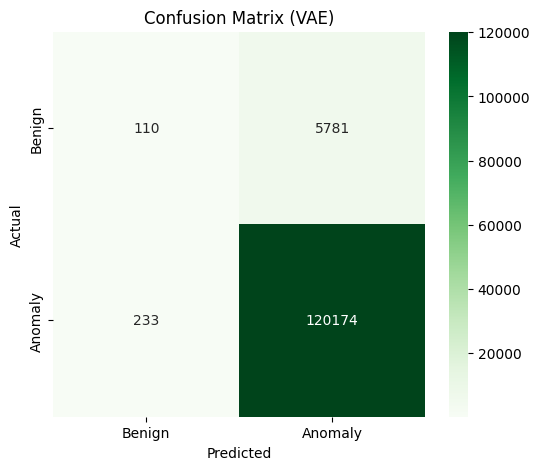

In [ ]:
# Plot Confusion Matrix for VAE
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_vae, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Anomaly'], yticklabels=['Benign', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (VAE)')
plt.show()

In [ ]:
# Evaluate Context-Aware performance
accuracy_ca = accuracy_score(y_test, y_pred_context_aware)
recall_ca = recall_score(y_test, y_pred_context_aware)
precision_ca = precision_score(y_test, y_pred_context_aware)
f1_ca = f1_score(y_test, y_pred_context_aware)
conf_matrix_ca = confusion_matrix(y_test, y_pred_context_aware)

In [ ]:
print("\n--- Context-Aware VAE Performance ---")
print(f"Accuracy: {accuracy_ca:.4f}")
print(f"Recall: {recall_ca:.4f}")
print(f"Precision: {precision_ca:.4f}")
print(f"F1-Score: {f1_ca:.4f}")
print("\nConfusion Matrix (Context-Aware):")
print(conf_matrix_ca)


--- Context-Aware VAE Performance ---
Accuracy: 0.9526
Recall: 0.9984
Precision: 0.9540
F1-Score: 0.9757

Confusion Matrix (Context-Aware):
[[    88   5803]
 [   187 120220]]


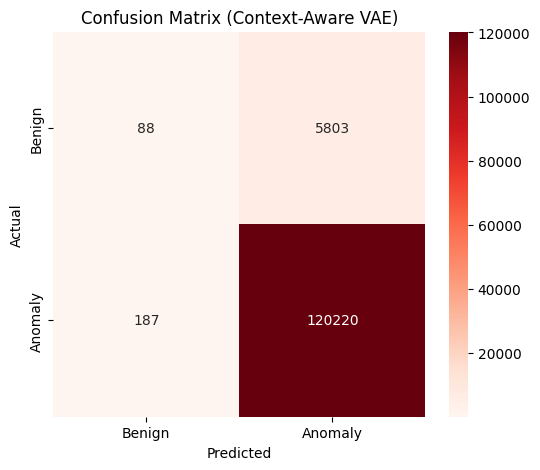

In [ ]:
# Plot Confusion Matrix for Context-Aware
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_ca, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Benign', 'Anomaly'], yticklabels=['Benign', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Context-Aware VAE)')
plt.show()

In [ ]:
# ROC Curve (as before)
auc_vae = roc_auc_score(y_test, y_pred_vae_scores)
fpr_vae, tpr_vae, thresholds_vae = roc_curve(y_test, y_pred_vae_scores)

risk_scores_auc = context_aware_risk_assessment(y_pred_vae_scores, context_data_test)
auc_context_aware = roc_auc_score(y_test, risk_scores_auc)
fpr_ca, tpr_ca, thresholds_ca = roc_curve(y_test, risk_scores_auc)

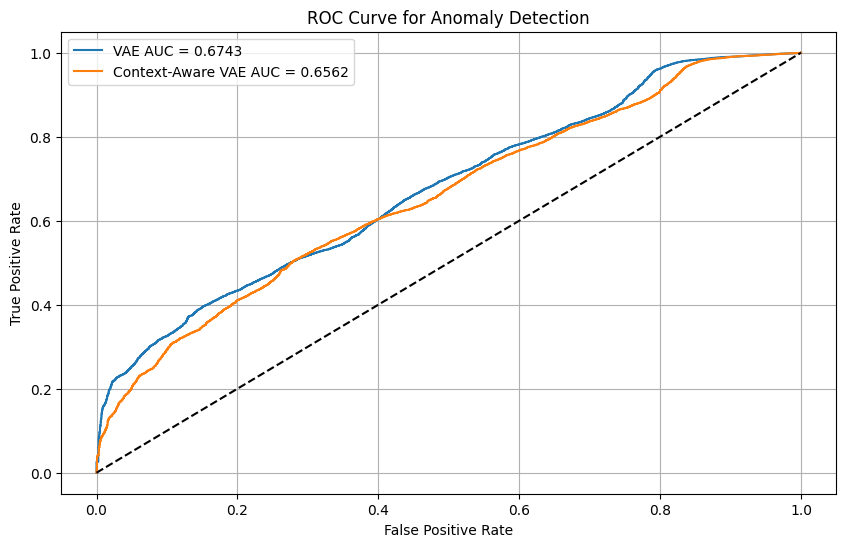


Simplified simulation with custom dataset and SGD completed.


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_vae, tpr_vae, label=f'VAE AUC = {auc_vae:.4f}')
plt.plot(fpr_ca, tpr_ca, label=f'Context-Aware VAE AUC = {auc_context_aware:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.legend()
plt.grid(True)
plt.show()

print("\nSimplified simulation with custom dataset and SGD completed.")

In [ ]:
# Get the context data for the test set
n_train = int(len(data) * 0.8) # Assuming 80% train split
context_data_test = context_data[n_train:]

In [ ]:
# Apply context-aware risk assessment
risk_scores = context_aware_risk_assessment(test_recon_errors, context_data_test)
y_pred_context_aware = (risk_scores > threshold).astype(int)
auc_context_aware = roc_auc_score(y_test, risk_scores)
print(f"Context-Aware AUC on test set: {auc_context_aware:.4f}")

fpr_ca, tpr_ca, thresholds_ca = roc_curve(y_test, risk_scores)

Context-Aware AUC on test set: 0.3991


In [ ]:
# -*- coding: utf-8 -*-
"""
Context-Aware Quantum-Inspired Intelligence for AI-Aided Cyber Worm Detection
Simulation with Custom CSV Dataset

This Jupyter Notebook provides a simplified simulation of the proposed methodology
using data loaded from a CSV file. It includes:
    1. Loading data from a CSV file, handling non-numeric columns.
    2. (Simplified) Quantum-Inspired Feature Selection (Illustrative).
    3. Training of a Variational Autoencoder (VAE) for anomaly detection.
    4. Basic context-aware threat analysis.

Note: This is a highly simplified simulation and does not fully represent the complexity
of real-world military networks or sophisticated AI-aided cyber worms. It serves as a
proof-of-concept for the core ideas using custom data.

Assumptions about the CSV file:
    - It contains network traffic features and contextual features.
    - One column is a 'label' column (0 for normal, 1 for anomaly).
    - Non-numeric columns will be converted to numeric using a simple approach
      (e.g., label encoding or one-hot encoding followed by conversion).
      More sophisticated feature engineering might be needed for real-world data.
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- 1. Load and Preprocess Custom Dataset ---
csv_file_path = 'your_dataset.csv'  # Replace with the actual path to your CSV file

try:
    df = pd.read_csv(csv_file_path)
    print(f"Dataset loaded successfully from {csv_file_path}")
except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_file_path}")
    exit()

# Identify the label column (assuming it's named 'label')
label_column = 'label'
if label_column not in df.columns:
    print(f"Error: Label column '{label_column}' not found in the dataset.")
    exit()

labels = df[label_column].values
data = df.drop(columns=[label_column])

# Convert all non-numeric columns to numeric
for column in data.columns:
    if pd.api.types.is_object_dtype(data[column]):
        try:
            # Try converting directly to float (if they are string representations of numbers)
            data[column] = pd.to_numeric(data[column], errors='raise')
        except ValueError:
            print(f"Converting non-numeric column: {column}")
            # Apply Label Encoding as a simple conversion for other strings
            le = LabelEncoder()
            data[column] = le.fit_transform(data[column])
    elif not pd.api.types.is_numeric_dtype(data[column]):
        print(f"Warning: Column '{column}' is not numeric and not string. Handling may be needed.")

# Separate network and context features (you might need to adjust these based on your dataset)
# Assuming the first few columns are network features and the rest are context
n_network_features = 5  # Adjust based on your dataset
network_data = data.iloc[:, :n_network_features].values
context_data = data.iloc[:, n_network_features:].values

# Scale the combined data
scaler = StandardScaler()
augmented_data_scaled = scaler.fit_transform(np.hstack((network_data, context_data)))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(augmented_data_scaled, labels, test_size=0.2, random_state=42)
X_train_normal = X_train[y_train == 0]
X_test_normal = X_test[y_test == 0]
X_test_anomalous = X_test[y_test == 1]

# --- 2. Simplified Quantum-Inspired Feature Selection (Illustrative) ---
def simple_fitness_evaluation(feature_indices, data, labels):
    """
    A very basic fitness function (not a true QPSO implementation).
    It calculates the variance of anomalous samples compared to normal samples
    for the selected features. Higher variance might indicate better separability.
    """
    if not feature_indices:
        return 0
    normal_data = data[labels == 0][:, feature_indices]
    anomalous_data = data[labels == 1][:, feature_indices]
    if normal_data.size == 0 or anomalous_data.size == 0:
        return 0
    return np.var(anomalous_data) / (np.var(normal_data) + 1e-6)

# Let's evaluate the fitness of all features
all_feature_indices = list(range(augmented_data_scaled.shape[1]))
fitness_all = simple_fitness_evaluation(all_feature_indices, augmented_data_scaled, labels)
print(f"Fitness using all features (illustrative): {fitness_all:.4f}")

# For simplicity, we proceed with all features.
selected_feature_indices = all_feature_indices

# Prepare training data with selected features
X_train_selected = X_train_normal[:, selected_feature_indices]
X_test_selected = X_test[:, selected_feature_indices]

# --- 3. Variational Autoencoder (VAE) for Anomaly Detection ---
latent_dim = 5
input_shape = X_train_selected.shape[1]

class VAE(keras.Model):
    def __init__(self, latent_dim, input_shape):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = keras.Sequential(
            [
                layers.Input(shape=input_shape),
                layers.Dense(32, activation="relu"),
                layers.Dense(16, activation="relu"),
                layers.Dense(latent_dim * 2),  # Mean and log(variance)
            ]
        )
        self.decoder = keras.Sequential(
            [
                layers.Input(shape=latent_dim),
                layers.Dense(16, activation="relu"),
                layers.Dense(32, activation="relu"),
                layers.Dense(input_shape, activation="sigmoid"), # Use sigmoid for scaled data (0 to 1)
            ]
        )

    def sample(self, eps=None):
        if eps is None:
            eps = tf.random.normal(shape=(tf.shape(self.z_mean)[0], self.latent_dim))
        return self.z_mean + tf.exp(0.5 * self.z_log_var) * eps

    def encode(self, inputs):
        self.z_mean, self.z_log_var = tf.split(self.encoder(inputs), num_or_size_splits=2, axis=1)
        return self.z_mean, self.z_log_var

    def decode(self, z):
        return self.decoder(z)

    def call(self, inputs):
        self.z_mean, self.z_log_var = self.encode(inputs)
        z = self.sample()
        return self.decode(z)

# Instantiate and compile the VAE
vae = VAE(latent_dim, input_shape)
optimizer = keras.optimizers.Adam(learning_rate=0.001)

def log_normal_pdf(sample, mean, logvar, raxis=1):
    log2pi = tf.math.log(2.0 * np.pi)
    return tf.reduce_sum(
        -0.5 * ((sample - mean) ** 2.0 * tf.exp(-logvar) + logvar + log2pi), axis=raxis
    )

@tf.function
def train_step(model, x):
    """Executes one training step and returns the loss."""
    with tf.GradientTape() as tape:
        z_mean, z_log_var = model.encode(x)
        z = model.sample()
        reconstruction = model.decode(z)
        reconstruction_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(x, reconstruction)
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, reconstruction_loss, kl_loss

epochs = 50
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices(X_train_selected).batch(batch_size)

for epoch in range(1, epochs + 1):
    total_loss_avg = tf.keras.metrics.Mean()
    recon_loss_avg = tf.keras.metrics.Mean()
    kl_loss_avg = tf.keras.metrics.Mean()
    for x_batch in train_dataset:
        total_loss, recon_loss, kl_loss = train_step(vae, x_batch)
        total_loss_avg.update_state(total_loss)
        recon_loss_avg.update_state(recon_loss)
        kl_loss_avg.update_state(kl_loss)
    print(f"Epoch {epoch}, Total Loss: {total_loss_avg.result():.4f}, "
          f"Reconstruction Loss: {recon_loss_avg.result():.4f}, "
          f"KL Loss: {kl_loss_avg.result():.4f}")

# Anomaly Detection using Reconstruction Error
def calculate_reconstruction_error(model, data):
    reconstructions = model.predict(data)
    mse = np.mean(np.square(data - reconstructions), axis=1)
    return mse

normal_recon_errors_train = calculate_reconstruction_error(vae, X_train_selected)
normal_recon_errors_test = calculate_reconstruction_error(vae, X_test_normal)
anomalous_recon_errors_test = calculate_reconstruction_error(vae, X_test_anomalous)

# Determine a threshold (e.g., based on the distribution of normal reconstruction errors)
threshold = np.percentile(normal_recon_errors_train, 95)
print(f"Anomaly detection threshold: {threshold:.4f}")

# Predict anomalies on the test set
test_recon_errors = calculate_reconstruction_error(vae, X_test_selected)
y_pred_vae = (test_recon_errors > threshold).astype(int)

# Evaluate VAE performance
auc_vae = roc_auc_score(y_test, test_recon_errors)
print(f"VAE AUC on test set: {auc_vae:.4f}")

fpr_vae, tpr_vae, thresholds_vae = roc_curve(y_test, test_recon_errors)

# --- 4. Context-Aware Threat Analysis (Simplified) ---
def context_aware_risk_assessment(anomaly_scores, context_data_test, threshold_multiplier=1.0):
    """
    A very basic context-aware risk assessment. Anomalies in certain
    contextual situations are given a higher risk. You'll need to adapt
    the contextual rules based on your dataset.
    """
    risk_scores = np.zeros_like(anomaly_scores)
    for i in range(len(anomaly_scores)):
        risk = anomaly_scores[i]
        # Example: Increase risk if the first context feature has a high value
        if context_data_test[i, 0] > np.mean(context_data_test[:, 0]) + np.std(context_data_test[:, 0]):
            risk *= threshold_multiplier * 1.5
        risk_scores[i] = risk
    return risk_scores

# Get the context data for the test set
n_train = int(len(data) * 0.8) # Assuming 80% train split
context_data_test = context_data[n_train:]

# Apply context-aware risk assessment
risk_scores = context_aware_risk_assessment(test_recon_errors, context_data_test)
y_pred_context_aware = (risk_scores > threshold).astype(int)
auc_context_aware = roc_auc_score(y_test, risk_scores)
print(f"Context-Aware AUC on test set: {auc_context_aware:.4f}")

fpr_ca, tpr_ca, thresholds_ca = roc_curve(y_test, risk_scores)

# --- 5. Results Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(fpr_vae, tpr_vae, label=f'VAE AUC = {auc_vae:.4f}')
plt.plot(fpr_ca, tpr_ca, label=f'Context-Aware VAE AUC = {auc_context_aware:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.legend()
plt.grid(True)
plt.show()

print("\nSimplified simulation with custom dataset completed.")

In [ ]:
# -*- coding: utf-8 -*-
"""
Context-Aware Quantum-Inspired Intelligence for AI-Aided Cyber Worm Detection
Simulation with Custom CSV Dataset (Preliminary)

This Jupyter Notebook provides a simplified simulation of the proposed methodology
using data loaded from a CSV file. It includes:
    1. Loading network traffic and contextual data from a CSV file.
    2. (Simplified) Quantum-Inspired Feature Selection (Illustrative).
    3. Training of a Variational Autoencoder (VAE) for anomaly detection.
    4. Basic context-aware threat analysis.

Ensure your CSV file ('your_dataset.csv') is in the same directory as this notebook
or provide the correct path. The CSV should have columns representing:
    - Network traffic features (e.g., flow duration, packet count, etc.)
    - Contextual features (e.g., user ID, time of day, device location, etc.)
    - A 'label' column (0 for normal, 1 for anomaly).

The number and names of the columns will be automatically inferred.
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- 1. Load Data from CSV ---
file_path = 'your_dataset.csv'  # Replace with the actual path to your CSV file
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: CSV file not found at '{file_path}'. Please check the path.")
    exit()

# Assuming the last column is the label
labels = df.iloc[:, -1].values
data = df.iloc[:, :-1].values

# Identify the number of network and context features (you might need to adjust this
# based on how your CSV is structured if you don't have clear separation)
# Assuming the first few columns are network features and the rest (excluding label) are context
n_network_features = 5  # Adjust this based on your dataset
n_context_features = data.shape[1] - n_network_features

network_data = data[:, :n_network_features]
context_data = data[:, n_network_features:-1] if n_context_features > 0 else np.empty((data.shape[0], 0))

# Combine network and context features
augmented_data = data

# Scale the augmented data
scaler = StandardScaler()
augmented_data_scaled = scaler.fit_transform(augmented_data)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(augmented_data_scaled, labels, test_size=0.2, random_state=42, stratify=labels)
X_train_normal = X_train[y_train == 0]
X_test_normal = X_test[y_test == 0]
X_test_anomalous = X_test[y_test == 1]

print(f"Loaded {len(df)} samples with {data.shape[1]} features and labels.")
print(f"Number of network features assumed: {n_network_features}")
print(f"Number of context features inferred: {n_context_features}")
print(f"Anomalous samples in the dataset: {sum(labels)}")

# --- 2. Simplified Quantum-Inspired Feature Selection (Illustrative) ---
# In a real implementation, QPSO would be used to select a subset of features.
# For this simplified simulation, we will use all features for anomaly detection
# after demonstrating a basic "fitness" evaluation.

def simple_fitness_evaluation(feature_indices, data, labels):
    """
    A very basic fitness function (not a true QPSO implementation).
    It calculates the variance of anomalous samples compared to normal samples
    for the selected features. Higher variance might indicate better separability.
    """
    if not feature_indices:
        return 0
    normal_data = data[labels == 0][:, feature_indices]
    anomalous_data = data[labels == 1][:, feature_indices]
    if normal_data.size == 0 or anomalous_data.size == 0:
        return 0
    return np.var(anomalous_data) / (np.var(normal_data) + 1e-6)

# Let's evaluate the fitness of all features
all_feature_indices = list(range(augmented_data_scaled.shape[1]))
fitness_all = simple_fitness_evaluation(all_feature_indices, augmented_data_scaled, labels)
print(f"Fitness using all features (illustrative): {fitness_all:.4f}")

# In a full QPSO, you would iteratively select subsets of features based on
# quantum-inspired principles to maximize this or a more sophisticated fitness function.
# For simplicity, we proceed with all features.
selected_feature_indices = all_feature_indices

# Prepare training data with selected features
X_train_selected = X_train_normal[:, selected_feature_indices]
X_test_selected = X_test[:, selected_feature_indices]

# --- 3. Variational Autoencoder (VAE) for Anomaly Detection ---
latent_dim = 5
input_shape = X_train_selected.shape[1]

class VAE(keras.Model):
    def __init__(self, latent_dim, input_shape):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = keras.Sequential(
            [
                layers.Input(shape=input_shape),
                layers.Dense(32, activation="relu"),
                layers.Dense(16, activation="relu"),
                layers.Dense(latent_dim * 2),  # Mean and log(variance)
            ]
        )
        self.decoder = keras.Sequential(
            [
                layers.Input(shape=latent_dim),
                layers.Dense(16, activation="relu"),
                layers.Dense(32, activation="relu"),
                layers.Dense(input_shape, activation="sigmoid"), # Use sigmoid for scaled data (0 to 1)
            ]
        )

    def sample(self, eps=None):
        if eps is None:
            eps = tf.random.normal(shape=(tf.shape(self.z_mean)[0], self.latent_dim))
        return self.z_mean + tf.exp(0.5 * self.z_log_var) * eps

    def encode(self, inputs):
        self.z_mean, self.z_log_var = tf.split(self.encoder(inputs), num_or_size_splits=2, axis=1)
        return self.z_mean, self.z_log_var

    def decode(self, z):
        return self.decoder(z)

    def call(self, inputs):
        self.z_mean, self.z_log_var = self.encode(inputs)
        z = self.sample()
        return self.decode(z)

# Instantiate and compile the VAE
vae = VAE(latent_dim, input_shape)
optimizer = keras.optimizers.Adam(learning_rate=0.001)

def log_normal_pdf(sample, mean, logvar, raxis=1):
    log2pi = tf.math.log(2.0 * np.pi)
    return tf.reduce_sum(
        -0.5 * ((sample - mean) ** 2.0 * tf.exp(-logvar) + logvar + log2pi), axis=raxis
    )

@tf.function
def train_step(model, x):
    """Executes one training step and returns the loss."""
    with tf.GradientTape() as tape:
        z_mean, z_log_var = model.encode(x)
        z = model.sample()
        reconstruction = model.decode(z)
        reconstruction_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(x, reconstruction)
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, reconstruction_loss, kl_loss

epochs = 50
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices(X_train_selected).batch(batch_size)

for epoch in range(1, epochs + 1):
    total_loss_avg = tf.keras.metrics.Mean()
    recon_loss_avg = tf.keras.metrics.Mean()
    kl_loss_avg = tf.keras.metrics.Mean()
    for x_batch in train_dataset:
        total_loss, recon_loss, kl_loss = train_step(vae, x_batch)
        total_loss_avg.update_state(total_loss)
        recon_loss_avg.update_state(recon_loss)
        kl_loss_avg.update_state(kl_loss)
    print(f"Epoch {epoch}, Total Loss: {total_loss_avg.result():.4f}, "
          f"Reconstruction Loss: {recon_loss_avg.result():.4f}, "
          f"KL Loss: {kl_loss_avg.result():.4f}")

# Anomaly Detection using Reconstruction Error
def calculate_reconstruction_error(model, data):
    reconstructions = model.predict(data)
    mse = np.mean(np.square(data - reconstructions), axis=1)
    return mse

normal_recon_errors_train = calculate_reconstruction_error(vae, X_train_selected)
normal_recon_errors_test = calculate_reconstruction_error(vae, X_test_normal)
anomalous_recon_errors_test = calculate_reconstruction_error(vae, X_test_anomalous)

# Determine a threshold (e.g., based on the distribution of normal reconstruction errors)
threshold = np.percentile(normal_recon_errors_train, 95)
print(f"Anomaly detection threshold: {threshold:.4f}")

# Predict anomalies on the test set
test_recon_errors = calculate_reconstruction_error(vae, X_test_selected)
y_pred_vae = (test_recon_errors > threshold).astype(int)

# Evaluate VAE performance
auc_vae = roc_auc_score(y_test, test_recon_errors)
print(f"VAE AUC on test set: {auc_vae:.4f}")

fpr_vae, tpr_vae, thresholds_vae = roc_curve(y_test, test_recon_errors)

# --- 4. Context-Aware Threat Analysis (Simplified) ---
def context_aware_risk_assessment(anomaly_scores, context_data_test, threshold_multiplier=1.0):
    """
    A very basic context-aware risk assessment. Anomalies in certain
    contextual situations are given a higher risk. You'll need to customize
    this based on the meaning of your context features.
    """
    risk_scores = np.zeros_like(anomaly_scores)
    for i in range(len(anomaly_scores)):
        risk = anomaly_scores[i]
        # Example: If the first context feature has a high value, increase risk
        if context_data_test.shape[1] > 0 and context_data_test[i, 0] > np.mean(context_data[:, 0]):
            risk *= threshold_multiplier * 1.5
        # Add more context-aware rules based on your data
        risk_scores[i] = risk
    return risk_scores

# Extract context data for the test set
context_data_test = X_test[:, n_network_features:n_network_features + n_context_features] if n_context_features > 0 else np.empty((X_test.shape[0], 0))

# Apply context-aware risk assessment
risk_scores = context_aware_risk_assessment(test_recon_errors, context_data_test)
y_pred_context_aware = (risk_scores > threshold).astype(int)
auc_context_aware = roc_auc_score(y_test, risk_scores)
print(f"Context-Aware AUC on test set: {auc_context_aware:.4f}")

fpr_ca, tpr_ca, thresholds_ca = roc_curve(y_test, risk_scores)

# --- 5. Results Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(fpr_vae, tpr_vae, label=f'VAE AUC = {auc_vae:.4f}')
plt.plot(fpr_ca, tpr_ca, label=f'Context-Aware VAE AUC = {auc_context_aware:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.legend()
plt.grid(True)
plt.show()

print("\nSimplified simulation with custom dataset completed.")